# Librerías

In [11]:
import struct
import os
# Manejo de datos
import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

# Copy
import copy

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE


# Construcción de la Red Neuronal (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay,fbeta_score)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificar si hay GPU disponible para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Librerías importadas. PyTorch utilizará el dispositivo: {device}")

Librerías importadas. PyTorch utilizará el dispositivo: cpu


# Importar imágenes

In [12]:
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        # Leer encabezado: numero magico, cantidad, filas, columnas
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f"Numero magico invalido: {magic}"
        # Leer todos los pixeles y convertir a numpy
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
        return images
def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
# Leer encabezado: numero magico y cantidad de etiquetas
        magic, num_labels = struct.unpack('>II', f.read(8))
        assert magic == 2049, f"Numero magico invalido: {magic}"
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

base_path = "datasets"
X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

print(f"X_train: {X_train.shape}") # (60000, 28, 28)
print(f"X_test: {X_test.shape}") # (10000, 28, 28)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


In [13]:
# (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat: {X_train_flat.shape}") # (60000, 784)
print(f"X_test_flat: {X_test_flat.shape}") # (10000, 784)

X_train_flat: (60000, 784)
X_test_flat: (10000, 784)


## Normalización

In [14]:
# Tomamos una muestra para el histograma 'antes'
muestra_antes = X_train_flat[0]

# 2. Normalización al rango [0, 1]
X_train_norm = X_train_flat.astype(np.float32) / 255.0
X_test_norm = X_test_flat.astype(np.float32) / 255.0

# Tomamos una muestra para el histograma 'después'
muestra_despues = X_train_norm[0]

# 3. Etiquetas a formato de PyTorch (enteros largos)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Forma original: {X_train.shape}")
print(f"Forma aplanada: {X_train_flat.shape}")

Forma original: (60000, 28, 28)
Forma aplanada: (60000, 784)


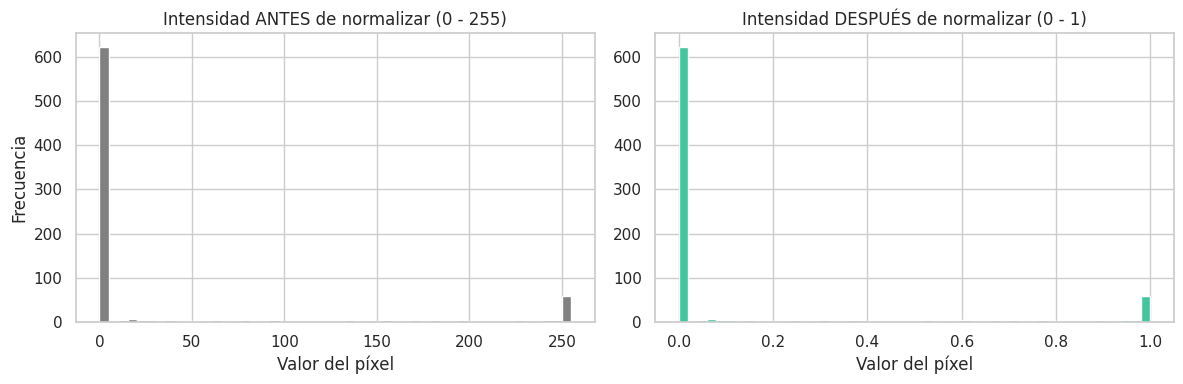

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma Antes
axes[0].hist(muestra_antes, bins=50, color='gray')
axes[0].set_title('Intensidad ANTES de normalizar (0 - 255)')
axes[0].set_xlabel('Valor del píxel')
axes[0].set_ylabel('Frecuencia')

# Histograma Después
axes[1].hist(muestra_despues, bins=50, color='#43C59E')
axes[1].set_title('Intensidad DESPUÉS de normalizar (0 - 1)')
axes[1].set_xlabel('Valor del píxel')

plt.tight_layout()
plt.show()

## One-Hot Encoding

In [22]:
def one_hot_encode(labels, num_classes=10):
    """Convierte etiquetas 0-9 en vectores one-hot de longitud 10."""
    return np.eye(num_classes)[labels]

y_train_onehot = one_hot_encode(y_train)
y_test_onehot = one_hot_encode(y_test)

print(f"y_train_onehot: {y_train_onehot.shape}") # (60000, 10)
print(f"y_test_onehot: {y_test_onehot.shape}") # (10000, 10)
N_CLASES = y_train_onehot.shape[1]

y_train_onehot: (60000, 10)
y_test_onehot: (10000, 10)


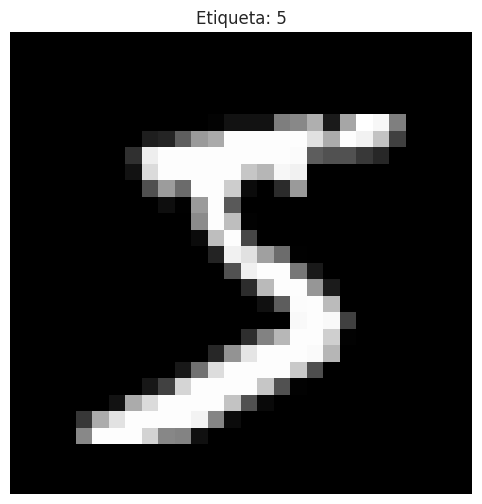

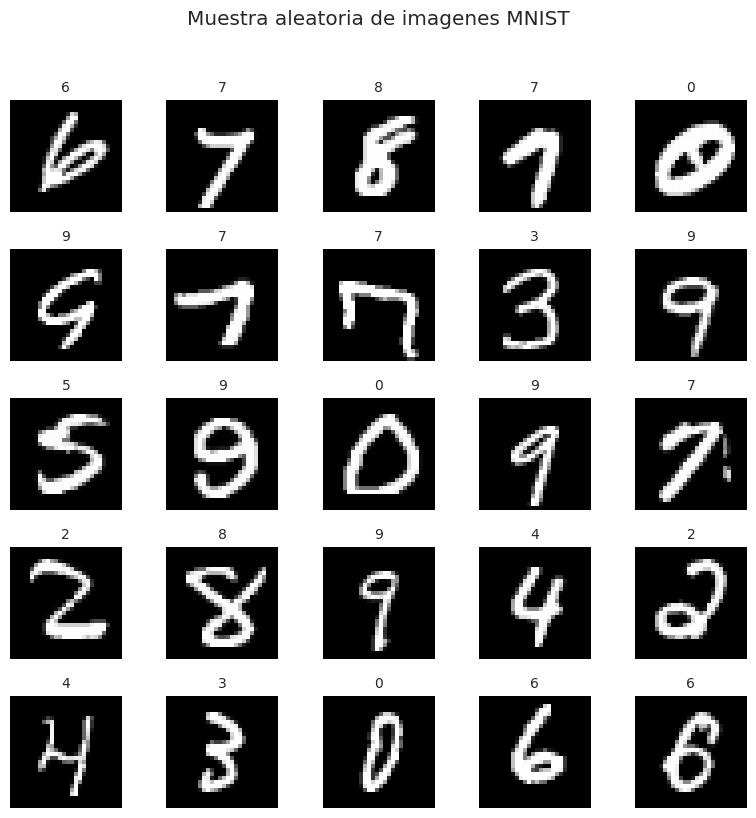

In [ ]:
# Visualizar una imagen individual
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

# Visualizar una grilla de 5x5 imagenes aleatorias
import numpy as np
indices = np.random.choice(len(X_train), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx], fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra aleatoria de imagenes MNIST", y=1.02)
plt.tight_layout()
plt.show()

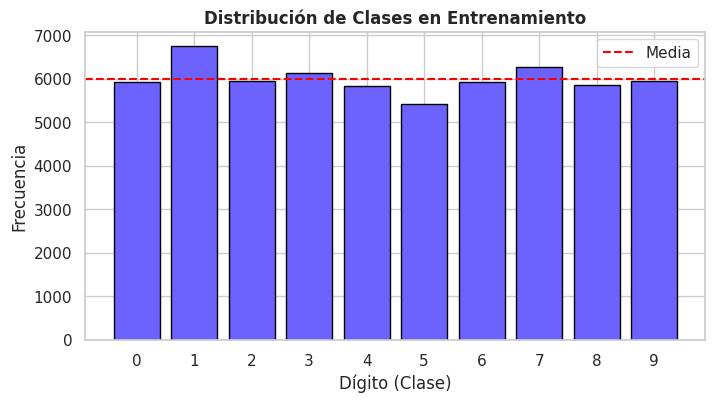

In [16]:
clases, frecuencias = np.unique(y_train_tensor, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(clases, frecuencias, color='#6C63FF', edgecolor='black')
plt.xticks(clases)
plt.title("Distribución de Clases en Entrenamiento", fontsize=12, fontweight='bold')
plt.xlabel("Dígito (Clase)")
plt.ylabel("Frecuencia")
plt.axhline(frecuencias.mean(), color='red', linestyle='--', label='Media')
plt.legend()
plt.show()

In [19]:
# Conclusión impresa sobre el balance
desviacion_maxima = (frecuencias.max() - frecuencias.min()) / frecuencias.mean() * 100
print(f"El dataset está razonablemente balanceado. La variación máxima entre la clase más y menos frecuente es de solo {desviacion_maxima:.1f}%.")

El dataset está razonablemente balanceado. La variación máxima entre la clase más y menos frecuente es de solo 22.0%.


Al convertir y_train_raw a torch.long, le estamos diciendo a PyTorch explícitamente: "Estas son etiquetas enteras, no matrices one-hot". Esta es la forma profesional y recomendada de manejar clasificación multiclase en PyTorch, ya que ahorra el gasto de memoria de crear una matriz de ceros y unos para 60.000 ejemplos.

In [26]:
# 3. Etiquetas a formato de PyTorch (enteros largos)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Forma original: {y_train_onehot.shape}")
print(f"Forma aplanada: {y_train_tensor.shape}")

Forma original: (60000, 10)
Forma aplanada: torch.Size([60000])


In [ ]:
#  PYTORCH — Clasificación Multiclase
# ─────────────────────────────────────────────────────────────────────────────
class ClasificacionMulticlaseNet_PyTorch(nn.Module):
    """
    Red para clasificación multiclase (5 categorías de noticias).
    Arquitectura: 30 → 128 → 64 → 5

    Diferencias clave respecto a la red binaria:
    1. La entrada tiene 30 features (antes eran 20)
    2. Las capas ocultas son más anchas (128 y 64 en vez de 64 y 32)
       ¿Por qué más anchas? Con 5 clases el problema es más complejo:
       la red necesita aprender a separar 5 territorios en el espacio de features
       en vez de solo 2. Más neuronas = más capacidad de representación.
    3. La capa de salida tiene N=5 neuronas (una por clase), no 1.
    4. CrossEntropyLoss (Softmax + CCE) en vez de BCEWithLogitsLoss.
    """

    def __init__(self, input_dim=int(X_train_flat.shape), n_clases=N_CLASES, dropout_rate=0.3):
        super().__init__()
        self.red = nn.Sequential(

            # ── CAPA OCULTA 1: 30 → 128 ───────────────────────────────────
            # Más neuronas que en binaria porque el problema es más complejo.
            # Parámetros: 128×30 + 128 = 3.968
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  # normaliza las 128 activaciones del batch
            nn.ReLU(),            # introduce no-linealidad
            nn.Dropout(dropout_rate),  # apaga el 30% aleatoriamente en training

            # ── CAPA OCULTA 2: 128 → 64 ───────────────────────────────────
            # Compresión progresiva: de 128 a 64 representaciones más abstractas.
            # Parámetros: 64×128 + 64 = 8.256
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # ── CAPA DE SALIDA: 64 → N_CLASES ─────────────────────────────
            # n_clases=5: una neurona por categoría de noticia.
            # Produce un vector de 5 logits (z_0, z_1, z_2, z_3, z_4).
            # SIN activación: CrossEntropyLoss aplica Softmax internamente.
            # ¿Por qué N neuronas en vez de 1?
            # Con 2 clases (binaria) bastaba 1 número (z>0 → clase 1).
            # Con N clases necesitamos N números para que la Softmax pueda
            # calcular una distribución de probabilidad sobre todas ellas.
            # Parámetros: 5×64 + 5 = 325
            nn.Linear(64, n_clases)
        )

        # Inicialización He para todas las capas lineales
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: forma (batch_size, 30) → batch de artículos de noticias
        salida: forma (batch_size, 5) → 5 logits por artículo

        A diferencia de la red binaria que hacía .squeeze(1),
        aquí devolvemos el tensor 2D completo porque CrossEntropyLoss
        espera (batch_size, n_clases) como predicciones y (batch_size,)
        como etiquetas.
        """
        return self.red(x)   # logits, forma: (batch, n_clases)


# Instanciar: 30 features de entrada, 5 clases, 30% dropout
modelo_mc_pt = ClasificacionMulticlaseNet_PyTorch(30, N_CLASES, 0.3)
print(f"\n  Arquitectura PyTorch (Multiclase):")
print(modelo_mc_pt)
total_params_mc = sum(p.numel() for p in modelo_mc_pt.parameters() if p.requires_grad)
print(f"   Total de parámetros entrenables: {total_params_mc:,}")

# Reutilizamos entrenar_pytorch_clasificacion con es_binario=False.
# Eso activa CrossEntropyLoss y dtype=torch.long para las etiquetas.
# batch_size=64: usamos un batch más grande que en binaria (32).
# ¿Por qué? Con 5 clases necesitamos que cada batch sea representativo
# de todas las categorías. Con batch=32 y 5 clases, estadísticamente
# cada batch tendría solo ~6 ejemplos por clase: poco para un gradiente estable.
# Con batch=64 tenemos ~13 por clase:
historial_mc_pt = entrenar_pytorch_clasificacion(
    modelo_mc_pt,
    X_train_norm, y_train_tensor,    # 30 features normalizadas, etiquetas enteras
    X_test_norm,  y_test_tensor,
    es_binario=False,  # activa CrossEntropyLoss y dtype=long
    epochs=300, batch_size=64, lr=1e-3, weight_decay=1e-4, patience=20
)

graficar_curvas(historial_mc_pt,
                'Clasificación Multiclase — PyTorch: Curvas de Entrenamiento',
                'mc_02_curvas_pytorch.png')

# ── Evaluación multiclase PyTorch ────────────────────────────────────────────
modelo_mc_pt.eval()
with torch.no_grad():
    # La red devuelve logits de forma (n_test, 5)
    logits_mc = modelo_mc_pt(torch.tensor(X_test_norm, dtype=torch.float32))

    # torch.softmax(logits, dim=1): aplica Softmax a lo largo de la dimensión
    # de las clases (dim=1). Para cada fila (ejemplo), normaliza los 5 logits
    # a una distribución de probabilidad que suma 1.
    # .numpy(): convierte a array de numpy para usar con sklearn
    probs_mc  = torch.softmax(logits_mc, dim=1).numpy()

    # logits_mc.argmax(dim=1): para cada fila, devuelve el índice del logit
    # mayor. Con Softmax monotónica, argmax(logits) = argmax(probabilidades).
    # No necesitamos aplicar Softmax para la decisión, solo para las probs.
    preds_mc  = logits_mc.argmax(dim=1).numpy()

acc_mc = accuracy_score(y_test_tensor, preds_mc)
print(f"\n📈 Evaluación PyTorch (Multiclase):")
print(f"   Accuracy: {acc_mc:.4f} ({acc_mc*100:.2f}%)")
print(f"\n   Reporte por clase:")
# classification_report con target_names asigna nombres a los índices 0,1,2,3,4
print(classification_report(y_test_tensor, preds_mc))

# Matriz de confusión multiclase
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Clasificación Multiclase PyTorch — Evaluación', fontweight='bold')

# cm_mc = confusion_matrix(y, preds_mc)
# sns.heatmap(cm_mc, annot=True, fmt='d', cmap='YlOrRd',
#             xticklabels=[str(c) for c in range(N_CLASES)],
#             yticklabels=CLASES_NOTICIAS, ax=axes[0])
# axes[0].set_title(f'Matriz de Confusión\n(Acc: {acc_mc:.3f})')
# axes[0].set_xlabel('Predicción')
# axes[0].set_ylabel('Clase real')

# Probabilidades de la clase correcta
probs_correctas = [probs_mc[i, y_test_tensor[i]] for i in range(len(y_test_tensor))]
axes[1].hist(probs_correctas, bins=30, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')
axes[1].axvline(np.mean(probs_correctas), color='blue', linestyle='-',
                label=f'Media: {np.mean(probs_correctas):.3f}')
axes[1].set_xlabel('P(clase correcta)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Probabilidad asignada a la clase real\n(alta → el modelo está seguro y correcto)')
axes[1].legend()

plt.tight_layout()
plt.savefig('mc_03_evaluacion_pytorch.png', dpi=120, bbox_inches='tight')
plt.show()
print("[Figura guardada: mc_03_evaluacion_pytorch.png]")
print("\n   📌 Interpretación de la matriz de confusión:")
print("   • La diagonal principal: clasificaciones correctas")
print("   • Fuera de la diagonal: errores (qué clases se confunden entre sí)")
print("   • Una diagonal perfecta = clasificador perfecto")